# EEG Eye-State · Multi-Trial RF — LOTO CV

Trains a Causal Random Forest on **all 10 trials** evaluated with Leave-One-Trial-Out cross-validation.

### Key differences from `eeg_causal_rf.ipynb`

| | Single-trial RF | **This notebook** |
|---|---|---|
| Training data | Trial 0 only (~20k windows) | All 10 trials pooled (~200k windows) |
| CV strategy | 5-fold GroupKFold | **LOTO** (Leave-One-Trial-Out) |
| Imbalance handling | `class_weight='balanced'` (Optuna) | `class_weight` in Optuna search — uses all data |

### LOTO strategy

Windows are built **per trial** (no cross-trial windows). For each fold:
- **Training:** all windows from the 9 other trials, `class_weight` tuned by Optuna
- **Test:** full held-out trial at natural class distribution → honest metrics

## 1 · Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
import logging
import os
import sys

import numpy as np
import optuna
import pandas as pd
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
)

import matplotlib
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from src.preprocessing import load_trial, build_windows

optuna.logging.set_verbosity(optuna.logging.WARNING)

DARK  = "#0a0e17"
CARD  = "#111827"
EDGE  = "#1f2937"
TEAL  = "#00e5cc"
CORAL = "#ff4f5e"
GOLD  = "#ffc947"
LIME  = "#a8ff3e"
WHITE = "#f0f4ff"
GRAY  = "#6b7280"

print("All imports OK.")

All imports OK.


## 2 · Config

In [ ]:
SUBJECT          = 9
TACHE            = "spt"
ALL_TRIALS       = list(range(10))
DATA_PATH        = f"../data/subject{SUBJECT}/"
FS               = 250
LP, HP           = 0.1, 60.0   # 0.1 Hz lower bound preserves MRCP (slow pre-movement drift)
TARGET           = "button"

N_TRIALS_OPTUNA  = 20
SMOOTH_WINDOW    = 125          # 500 ms at 250 Hz

# ── Speed knobs ───────────────────────────────────────────────────────────
T_MAX            = 500             # pre-compute windows here; RF search range is 16–T_MAX
OPTUNA_FOLDS     = ALL_TRIALS[::2] # 5 folds during search (every other trial)
# LightGBM (§14)
N_ESTIMATORS_LGB = 500             # upper bound — early stopping determines actual count
EARLY_STOP_LGB   = 30              # patience rounds

## 3 · Load & Filter All Trials

In [3]:
print("Loading and filtering all trials …")
raw_data = {}   # trial → (X_array, y_array)
EEG_COLS = None

for t in ALL_TRIALS:
    df, cols = load_trial(SUBJECT, TACHE, t, DATA_PATH, eeg_cols=EEG_COLS, lp=LP, hp=HP)
    if EEG_COLS is None:
        EEG_COLS = cols
    X_t = df[EEG_COLS].values.astype(np.float32)
    y_t = df[TARGET].values.astype(int)
    raw_data[t] = (X_t, y_t)
    n_open   = int(y_t.sum())
    n_closed = int((y_t == 0).sum())
    print(
        f"  trial {t:2d}: {len(df):6,} samples  "
        f"open={n_open:5,} ({n_open/len(df)*100:.1f}%)  "
        f"closed={n_closed:6,}"
    )

N_CHANNELS = len(EEG_COLS)
print(f"\nChannels ({N_CHANNELS}): {EEG_COLS}")

Loading and filtering all trials …
Setting up band-pass filter from 0.1 - 60 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 60.00 Hz
- Upper transition bandwidth: 15.00 Hz (-6 dB cutoff frequency: 67.50 Hz)
- Filter length: 8251 samples (33.004 s)

  trial  0: 20,338 samples  open=1,626 (8.0%)  closed=18,712
Setting up band-pass filter from 0.1 - 60 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper 

## 4 · Build Windows Helper

In [ ]:
# ── Pre-compute windows at T_MAX once ────────────────────────────────────
# Avoids rebuilding the full window set for every Optuna trial.
# build_windows returns (M, T*C) time-major; reshape to (M, T, C) for slicing.
print(f"Pre-computing windows at T_MAX={T_MAX} …")
_X_raw, _y_raw, _tid_raw = [], [], []
for _t in ALL_TRIALS:
    X_t, y_t = raw_data[_t]
    Xw, yw = build_windows(X_t, y_t, T_MAX, per_window_norm=False)
    _X_raw.append(Xw.reshape(-1, T_MAX, N_CHANNELS))
    _y_raw.append(yw)
    _tid_raw.append(np.full(len(yw), _t, dtype=np.int32))

_X_max   = np.concatenate(_X_raw)    # (M, T_MAX, C)
_y_max   = np.concatenate(_y_raw)
_tid_max = np.concatenate(_tid_raw)
del _X_raw, _y_raw, _tid_raw
n_press_total = int(_y_max.sum())
print(f"  shape={_X_max.shape}  memory={_X_max.nbytes/1e9:.2f} GB")
print(f"  windows={len(_y_max):,}  press={n_press_total:,} ({n_press_total/len(_y_max)*100:.1f}%)")


def get_windows_for_T(T: int):
    """Slice pre-computed T_MAX array to T lags + vectorised per-window normalisation."""
    X = _X_max[:, T_MAX - T:, :].copy()  # (M, T, C)
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-8
    return ((X - mu) / sd).reshape(len(_y_max), T * N_CHANNELS), _y_max, _tid_max

## 5 · Optuna Hyperparameter Search

**Objective:** mean LOTO AUC across all 10 trials.  
Each fold trains on all windows from 9 trials and evaluates on the full held-out trial.

**Speed optimisations applied:**
- Windows pre-computed at T_MAX; each trial just slices — no rebuild
- **5 LOTO folds** during search (every other trial); full 10-fold run in §7

In [ ]:
def objective(trial):
    T              = trial.suggest_int("T", 16, T_MAX, log=True)
    n_estimators   = trial.suggest_int("n_estimators", 50, 300, log=True)
    max_depth      = trial.suggest_categorical("max_depth", [None, 5, 10, 20, 30])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features   = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.1, 0.3])
    class_weight   = trial.suggest_categorical("class_weight", ["balanced", None])

    X_p, y_p, tid_p = get_windows_for_T(T)  # fast slice — no rebuild

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=42,
    )

    fold_aucs = []
    for fold, test_trial in enumerate(OPTUNA_FOLDS):
        te_mask = tid_p == test_trial
        X_te, y_te = X_p[te_mask], y_p[te_mask]
        X_tr, y_tr = X_p[~te_mask], y_p[~te_mask]

        clf.fit(X_tr, y_tr)
        probs = clf.predict_proba(X_te)[:, 1]
        auc   = roc_auc_score(y_te, probs)
        fold_aucs.append(auc)

        trial.report(np.mean(fold_aucs), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_aucs))


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

print(f"\nBest trial : #{study.best_trial.number}")
print(f"Best AUC   : {study.best_value:.4f}")
print("\nBest params:")
for k, v in study.best_params.items():
    print(f"  {k:22s}: {v}")

## 6 · Extract Best Config & Rebuild Dataset

In [ ]:
p = study.best_params

T                 = p["T"]
n_estimators      = p["n_estimators"]
max_depth         = p["max_depth"]
min_samples_split = p["min_samples_split"]
min_samples_leaf  = p["min_samples_leaf"]
max_features      = p["max_features"]
class_weight      = p["class_weight"]

X_pool, y_pool, tid_pool = get_windows_for_T(T)

print(f"Best T        : {T} samples  ({T/FS*1000:.0f} ms look-back)")
print(f"Feature vector: {N_CHANNELS} channels × {T} lags = {N_CHANNELS*T} features")
print(f"Total windows : {len(y_pool):,}  (press={y_pool.sum():,}  not-pressed={(y_pool==0).sum():,})")
print(f"n_estimators  : {n_estimators}")
print(f"max_depth     : {max_depth}")
print(f"max_features  : {max_features}")
print(f"class_weight  : {class_weight}")

## 7 · Final LOTO Evaluation

Each fold: train on all windows from 9 trials, evaluate on the full held-out trial.

In [7]:
final_aucs = []
all_probs  = np.zeros(len(y_pool), dtype=np.float32)
all_preds  = np.full(len(y_pool), -1, dtype=int)

best_clf = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    max_features=max_features,
    class_weight=class_weight,
    n_jobs=-1,
    random_state=42,
)

for test_trial in ALL_TRIALS:
    te_mask = tid_pool == test_trial
    X_te, y_te = X_pool[te_mask], y_pool[te_mask]
    X_tr, y_tr = X_pool[~te_mask], y_pool[~te_mask]

    best_clf.fit(X_tr, y_tr)
    probs = best_clf.predict_proba(X_te)[:, 1]
    preds = (probs >= 0.5).astype(int)
    auc   = roc_auc_score(y_te, probs)

    all_probs[te_mask] = probs
    all_preds[te_mask] = preds
    final_aucs.append(auc)
    print(
        f"  trial {test_trial:2d} (test)  AUC={auc:.4f}  "
        f"n={te_mask.sum():,}  press%={y_te.mean()*100:.1f}%"
    )

mask = all_preds >= 0
print(f"\nMean LOTO AUC : {np.mean(final_aucs):.4f} ± {np.std(final_aucs):.4f}")
print(f"Accuracy @ 0.5: {(all_preds[mask] == y_pool[mask]).mean():.4f}")
print()
print(classification_report(y_pool[mask], all_preds[mask], target_names=["Not pressed", "Pressed"]))

fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_pool[mask], all_probs[mask])
best_thresh   = float(thresholds_cv[np.argmax(tpr_cv - fpr_cv)])
all_preds_opt = (all_probs >= best_thresh).astype(int)
print(f"Optimal threshold (Youden's J): {best_thresh:.3f}")
print(f"Accuracy @ optimal threshold  : {(all_preds_opt[mask] == y_pool[mask]).mean():.4f}")
print()
print(classification_report(y_pool[mask], all_preds_opt[mask], target_names=["Not pressed", "Pressed"]))

print("Refitting on all data …")
best_clf.fit(X_pool, y_pool)
importances = best_clf.feature_importances_

print("Calibrating probabilities (isotonic, 5-fold) …")
calibrated_clf = CalibratedClassifierCV(
    RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=42,
    ),
    cv=5,
    method="isotonic",
)
calibrated_clf.fit(X_pool, y_pool)
print("Done.")

  trial  0 (test)  AUC=0.7879  n=20,059  press%=8.1%
  trial  1 (test)  AUC=0.6808  n=16,308  press%=15.4%

Mean LOTO AUC : 0.7343 ± 0.0536
Accuracy @ 0.5: 0.8175

              precision    recall  f1-score   support

 Not pressed       0.93      0.85      0.89     32233
     Pressed       0.32      0.53      0.40      4134

    accuracy                           0.82     36367
   macro avg       0.63      0.69      0.64     36367
weighted avg       0.86      0.82      0.84     36367

Optimal threshold (Youden's J): 0.444
Accuracy @ optimal threshold  : 0.7867

              precision    recall  f1-score   support

 Not pressed       0.94      0.81      0.87     32233
     Pressed       0.28      0.58      0.38      4134

    accuracy                           0.79     36367
   macro avg       0.61      0.70      0.63     36367
weighted avg       0.86      0.79      0.82     36367

Refitting on all data …
Calibrating probabilities (isotonic, 5-fold) …
Done.


## 8 · Temporal Smoothing + Optimal Threshold

Causal 500 ms rolling mean collapses sub-second false positive spikes.  
Smoothing is applied **per trial** (probabilities should not bleed across trial boundaries).

In [8]:
def smooth_probs(probs, window=SMOOTH_WINDOW):
    """Causal rolling-mean smoother — collapses sub-second spikes."""
    return (
        pd.Series(probs)
        .rolling(window=window, min_periods=1)
        .mean()
        .values.astype(np.float32)
    )


all_probs_smooth = np.zeros_like(all_probs)
for t in ALL_TRIALS:
    te_mask = tid_pool == t
    all_probs_smooth[te_mask] = smooth_probs(all_probs[te_mask])

fpr_s, tpr_s, thr_s = roc_curve(y_pool[mask], all_probs_smooth[mask])
best_thresh_smooth = float(thr_s[np.argmax(tpr_s - fpr_s)])
all_preds_smooth   = (all_probs_smooth >= best_thresh_smooth).astype(int)

auc_smooth = roc_auc_score(y_pool[mask], all_probs_smooth[mask])
acc_smooth = (all_preds_smooth[mask] == y_pool[mask]).mean()

print(f"Smoothing window : {SMOOTH_WINDOW} samples ({SMOOTH_WINDOW/FS*1000:.0f} ms)")
print(f"AUC              : {auc_smooth:.4f}  (unsmoothed: {np.mean(final_aucs):.4f})")
print(f"Threshold        : {best_thresh_smooth:.3f}  (unsmoothed: {best_thresh:.3f})")
print(f"Accuracy         : {acc_smooth:.4f}")
print()
print(classification_report(y_pool[mask], all_preds_smooth[mask], target_names=["Closed", "Open"]))

best_thresh   = best_thresh_smooth
all_preds_opt = all_preds_smooth

Smoothing window : 125 samples (500 ms)
AUC              : 0.6490  (unsmoothed: 0.7343)
Threshold        : 0.414  (unsmoothed: 0.444)
Accuracy         : 0.7417

              precision    recall  f1-score   support

      Closed       0.92      0.77      0.84     32233
        Open       0.22      0.49      0.30      4134

    accuracy                           0.74     36367
   macro avg       0.57      0.63      0.57     36367
weighted avg       0.84      0.74      0.78     36367



## 9 · Results Summary

In [9]:
print("=" * 60)
print("  EEG Eye-State — Multi-Trial RF Results (LOTO CV)")
print("=" * 60)
print(f"  Look-back window  : T = {T} samples  ({T/FS*1000:.0f} ms)")
print(f"  Feature vector    : {N_CHANNELS} channels × {T} lags = {N_CHANNELS*T} features")
print(f"  Training trials   : all {len(ALL_TRIALS)}")
print()
print(f"  Best Optuna AUC   : {study.best_value:.4f}")
print(f"  LOTO AUC (final)  : {np.mean(final_aucs):.4f} ± {np.std(final_aucs):.4f}")
print(f"  Smooth AUC        : {auc_smooth:.4f}")
print(f"  Threshold         : {best_thresh:.3f}  (Youden's J, post-smoothing)")
print(f"  Accuracy          : {acc_smooth:.4f}")
print()
print("  Best RF Config")
print(f"    n_estimators      : {n_estimators}")
print(f"    max_depth         : {max_depth}")
print(f"    min_samples_split : {min_samples_split}")
print(f"    min_samples_leaf  : {min_samples_leaf}")
print(f"    max_features      : {max_features}")
print(f"    class_weight      : {class_weight}")
print("=" * 60)

  EEG Eye-State — Multi-Trial RF Results (LOTO CV)
  Look-back window  : T = 279 samples  (1116 ms)
  Feature vector    : 16 channels × 279 lags = 4464 features
  Training trials   : all 2

  Best Optuna AUC   : 0.7343
  LOTO AUC (final)  : 0.7343 ± 0.0536
  Smooth AUC        : 0.6490
  Threshold         : 0.414  (Youden's J, post-smoothing)
  Accuracy          : 0.7417

  Best RF Config
    n_estimators      : 172
    max_depth         : 5
    min_samples_split : 13
    min_samples_leaf  : 8
    max_features      : 0.3
    class_weight      : balanced


## 10 · 3-Panel Plot per Trial

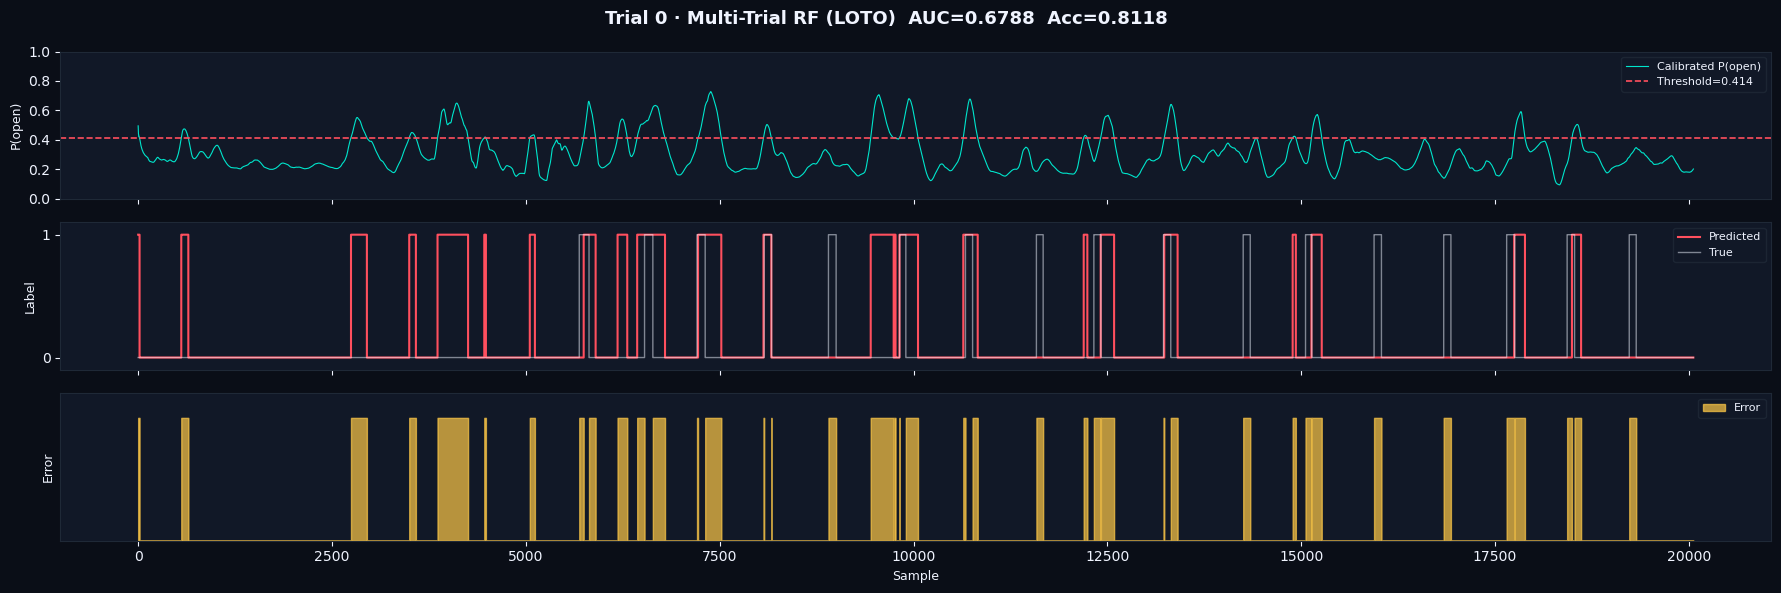

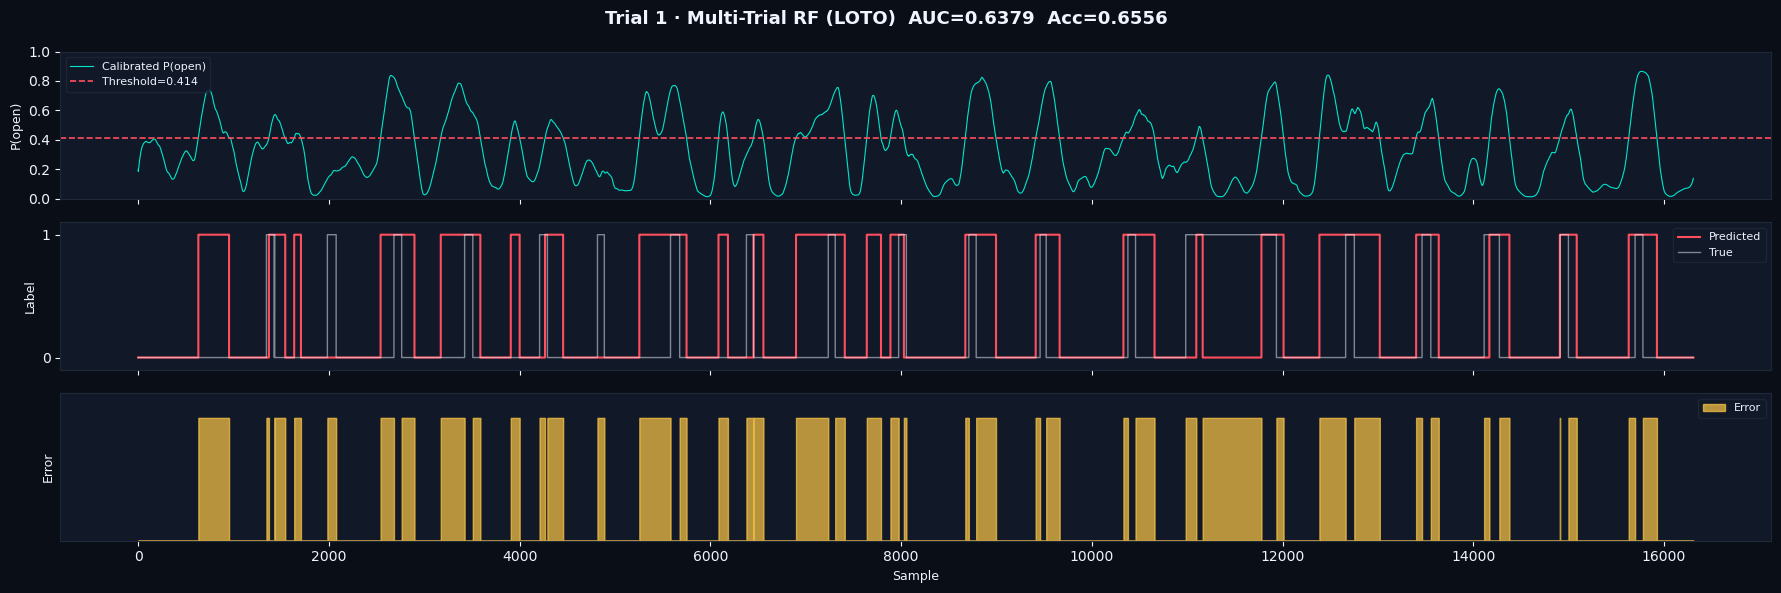

In [10]:
%matplotlib inline

for test_trial in ALL_TRIALS:
    te_mask = tid_pool == test_trial
    probs_t = all_probs_smooth[te_mask]
    preds_t = all_preds_opt[te_mask]
    y_t     = y_pool[te_mask]
    auc_t   = roc_auc_score(y_t, probs_t)
    acc_t   = (preds_t == y_t).mean()

    fig, axes = plt.subplots(3, 1, figsize=(18, 6), sharex=True, facecolor=DARK)
    t_axis = np.arange(len(probs_t))

    ax = axes[0]
    ax.set_facecolor(CARD)
    ax.plot(t_axis, probs_t, color=TEAL, lw=0.8, label="Calibrated P(open)")
    ax.axhline(best_thresh, color=CORAL, lw=1.2, ls="--",
               label=f"Threshold={best_thresh:.3f}")
    ax.set_ylim(0, 1)
    ax.set_ylabel("P(open)", color=WHITE, fontsize=9)
    ax.tick_params(colors=WHITE)
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
    for sp in ax.spines.values():
        sp.set_color(EDGE)

    ax = axes[1]
    ax.set_facecolor(CARD)
    ax.plot(t_axis, preds_t, drawstyle="steps-post", color=CORAL, lw=1.5, label="Predicted")
    ax.plot(t_axis, y_t,     drawstyle="steps-post", color=WHITE, lw=1.0, alpha=0.5, label="True")
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])
    ax.set_ylabel("Label", color=WHITE, fontsize=9)
    ax.tick_params(colors=WHITE)
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
    for sp in ax.spines.values():
        sp.set_color(EDGE)

    ax = axes[2]
    ax.set_facecolor(CARD)
    errors = (preds_t != y_t).astype(float)
    ax.fill_between(t_axis, errors, color=GOLD, alpha=0.7, step="post", label="Error")
    ax.set_ylim(0, 1.2)
    ax.set_yticks([])
    ax.set_ylabel("Error", color=WHITE, fontsize=9)
    ax.set_xlabel("Sample", color=WHITE, fontsize=9)
    ax.tick_params(colors=WHITE)
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
    for sp in ax.spines.values():
        sp.set_color(EDGE)

    fig.suptitle(
        f"Trial {test_trial} · Multi-Trial RF (LOTO)  AUC={auc_t:.4f}  Acc={acc_t:.4f}",
        color=WHITE, fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

## 11 · Feature Importance Heatmap

Importance reshaped to `(C, T)` — shows which channels and temporal lags the forest relies on most.

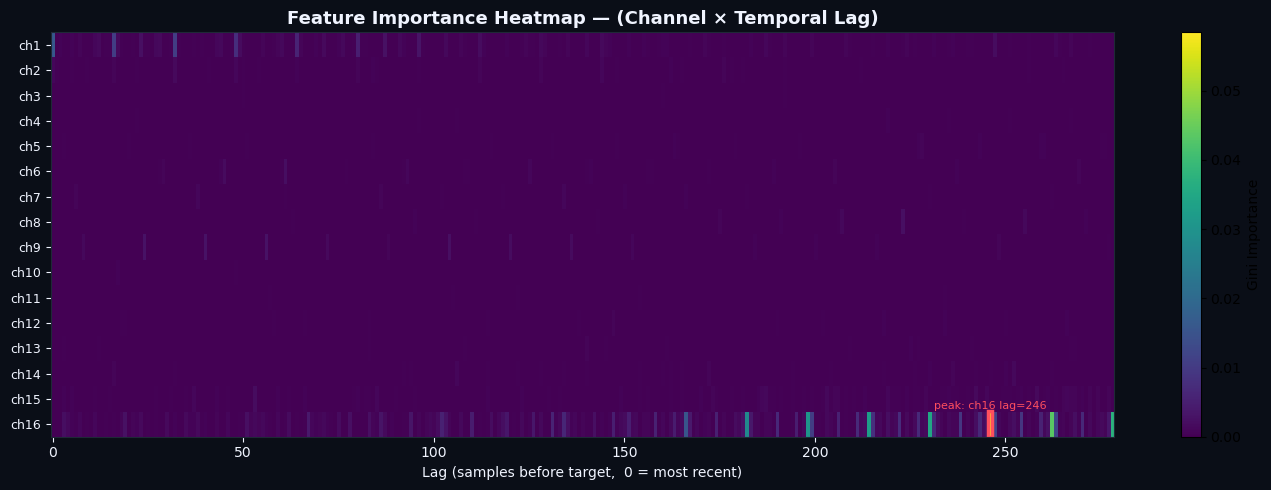

In [11]:
imp_matrix = importances.reshape(N_CHANNELS, T)

fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)

im = ax.imshow(imp_matrix, aspect="auto", cmap="viridis", interpolation="nearest")
plt.colorbar(im, ax=ax, label="Gini Importance")

ax.set_yticks(range(N_CHANNELS))
ax.set_yticklabels(EEG_COLS, color=WHITE, fontsize=9)
ax.set_xlabel(f"Lag (samples before target,  0 = most recent)", color=WHITE, fontsize=10)
ax.set_title(
    "Feature Importance Heatmap — (Channel × Temporal Lag)",
    color=WHITE, fontsize=13, fontweight="bold",
)
ax.tick_params(colors=WHITE)

best_ch, best_lag = np.unravel_index(imp_matrix.argmax(), imp_matrix.shape)
ax.add_patch(
    plt.Rectangle((best_lag - 0.5, best_ch - 0.5), 1, 1,
                  fill=False, edgecolor=CORAL, lw=2.5)
)
ax.text(
    best_lag, best_ch - 0.6,
    f"peak: {EEG_COLS[best_ch]} lag={best_lag}",
    color=CORAL, fontsize=8, ha="center",
)
plt.tight_layout()

## 12 · Per-Channel Total Importance

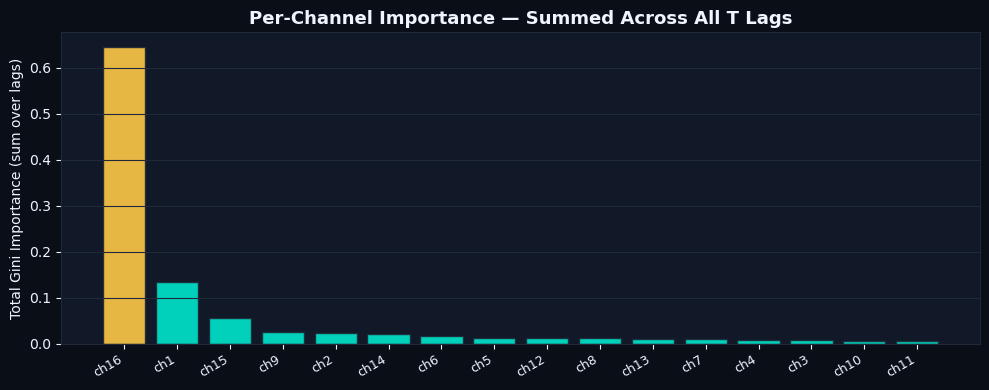

In [12]:
ch_importance = imp_matrix.sum(axis=1)
order = np.argsort(ch_importance)[::-1]

fig, ax = plt.subplots(figsize=(10, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)

bar_colours = [GOLD if i == 0 else TEAL for i in range(N_CHANNELS)]
ax.bar(
    range(N_CHANNELS),
    ch_importance[order],
    color=bar_colours,
    alpha=0.9,
    edgecolor=EDGE,
)
ax.set_xticks(range(N_CHANNELS))
ax.set_xticklabels(
    [EEG_COLS[i] for i in order], color=WHITE, fontsize=9, rotation=30, ha="right"
)
ax.set_ylabel("Total Gini Importance (sum over lags)", color=WHITE, fontsize=10)
ax.set_title(
    "Per-Channel Importance — Summed Across All T Lags",
    color=WHITE, fontsize=13, fontweight="bold",
)
ax.tick_params(colors=WHITE)
ax.yaxis.grid(True, color=EDGE, lw=0.8)
plt.tight_layout()

## 13 · Save Model

In [13]:
import json
import joblib

SAVE_PATH = f"../data/subject{SUBJECT}/model_multitrial"
os.makedirs(SAVE_PATH, exist_ok=True)

joblib.dump(best_clf,       f"{SAVE_PATH}/eeg_rf_model.joblib")
joblib.dump(calibrated_clf, f"{SAVE_PATH}/eeg_rf_calibrated.joblib")

params_to_save = {
    "T":                  int(T),
    "n_estimators":       int(n_estimators),
    "max_depth":          max_depth,
    "min_samples_split":  int(min_samples_split),
    "min_samples_leaf":   int(min_samples_leaf),
    "max_features":       max_features,
    "class_weight":       class_weight,
    "best_loto_auc":      float(np.mean(final_aucs)),
    "best_thresh":        float(best_thresh),
    "smooth_window":      int(SMOOTH_WINDOW),
    "n_channels":         int(N_CHANNELS),
    "channel_names":      EEG_COLS,
    "fs":                 int(FS),
    "per_window_norm":    True,
    "n_trials_trained":   len(ALL_TRIALS),
}
with open(f"{SAVE_PATH}/eeg_rf_params.json", "w") as f:
    json.dump(params_to_save, f, indent=2)

print("Saved:")
print(f"  {SAVE_PATH}/eeg_rf_model.joblib       (raw RF — feature importance)")
print(f"  {SAVE_PATH}/eeg_rf_calibrated.joblib  (calibrated — use for inference)")
print(f"  {SAVE_PATH}/eeg_rf_params.json         (T={T}, thresh={best_thresh:.3f})")

Saved:
  ../data/subject9/model_multitrial/eeg_rf_model.joblib       (raw RF — feature importance)
  ../data/subject9/model_multitrial/eeg_rf_calibrated.joblib  (calibrated — use for inference)
  ../data/subject9/model_multitrial/eeg_rf_params.json         (T=279, thresh=0.414)


## 14 · LightGBM Alternative

Gradient boosted trees — typically faster and more accurate than RF on tabular data.  
Uses leaf-wise tree growth (`max_depth=-1`, `num_leaves` controls complexity).  
T is re-searched independently since the optimal look-back may differ from the RF.

In [15]:
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)


In [ ]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score

N_TRIALS_LGB = 20


def objective_lgb(trial):
    T_lgb             = trial.suggest_int("T", 16, T_MAX, log=True)
    num_leaves        = trial.suggest_int("num_leaves", 15, 255, log=True)
    learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    min_child_samples = trial.suggest_int("min_child_samples", 5, 100, log=True)
    subsample         = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    class_weight      = trial.suggest_categorical("class_weight", ["balanced", None])

    X_p, y_p, tid_p = get_windows_for_T(T_lgb)  # fast slice — no rebuild

    clf = lgb.LGBMClassifier(
        n_estimators=N_ESTIMATORS_LGB,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        class_weight=class_weight,
        max_depth=-1,
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )

    fold_aucs = []
    for fold, test_trial in enumerate(OPTUNA_FOLDS):
        te_mask = tid_p == test_trial
        X_te, y_te = X_p[te_mask], y_p[te_mask]
        X_tr_full, y_tr_full = X_p[~te_mask], y_p[~te_mask]

        n_val = max(1, int(0.1 * len(y_tr_full)))
        X_tr, y_tr   = X_tr_full[n_val:], y_tr_full[n_val:]
        X_val, y_val = X_tr_full[:n_val], y_tr_full[:n_val]

        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(EARLY_STOP_LGB, verbose=False), lgb.log_evaluation(-1)],
        )
        probs = clf.predict_proba(X_te)[:, 1]
        auc   = roc_auc_score(y_te, probs)
        fold_aucs.append(auc)

        trial.report(np.mean(fold_aucs), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_aucs))


study_lgb = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS_LGB, show_progress_bar=True)

print(f"\nBest trial : #{study_lgb.best_trial.number}")
print(f"Best AUC   : {study_lgb.best_value:.4f}")
print("\nBest params:")
for k, v in study_lgb.best_params.items():
    print(f"  {k:22s}: {v}")

In [ ]:
p_lgb = study_lgb.best_params
T_lgb          = p_lgb["T"]
num_leaves_lgb = p_lgb["num_leaves"]
lr_lgb         = p_lgb["learning_rate"]
min_child_lgb  = p_lgb["min_child_samples"]
subsample_lgb  = p_lgb["subsample"]
colsample_lgb  = p_lgb["colsample_bytree"]
cw_lgb         = p_lgb["class_weight"]

X_pool_lgb, y_pool_lgb, tid_pool_lgb = get_windows_for_T(T_lgb)

final_aucs_lgb  = []
all_probs_lgb   = np.zeros(len(y_pool_lgb), dtype=np.float32)
all_preds_lgb   = np.full(len(y_pool_lgb), -1, dtype=int)
n_trees_lgb     = []

for test_trial in ALL_TRIALS:
    te_mask = tid_pool_lgb == test_trial
    X_te, y_te = X_pool_lgb[te_mask], y_pool_lgb[te_mask]
    X_tr_full, y_tr_full = X_pool_lgb[~te_mask], y_pool_lgb[~te_mask]

    n_val = max(1, int(0.1 * len(y_tr_full)))
    X_tr, y_tr   = X_tr_full[n_val:], y_tr_full[n_val:]
    X_val, y_val = X_tr_full[:n_val], y_tr_full[:n_val]

    clf = lgb.LGBMClassifier(
        n_estimators=N_ESTIMATORS_LGB,
        num_leaves=num_leaves_lgb,
        learning_rate=lr_lgb,
        min_child_samples=min_child_lgb,
        subsample=subsample_lgb,
        colsample_bytree=colsample_lgb,
        class_weight=cw_lgb,
        max_depth=-1,
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )
    clf.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(EARLY_STOP_LGB, verbose=False), lgb.log_evaluation(-1)],
    )
    n_trees_lgb.append(clf.best_iteration_)

    probs = clf.predict_proba(X_te)[:, 1]
    preds = (probs >= 0.5).astype(int)
    auc   = roc_auc_score(y_te, probs)

    all_probs_lgb[te_mask] = probs
    all_preds_lgb[te_mask] = preds
    final_aucs_lgb.append(auc)
    print(f"  trial {test_trial:2d} (test)  AUC={auc:.4f}  trees={clf.best_iteration_:3d}  n={te_mask.sum():,}  press%={y_te.mean()*100:.1f}%")

n_est_lgb = int(np.median(n_trees_lgb))
mask_lgb = all_preds_lgb >= 0
print(f"\nMean LOTO AUC : {np.mean(final_aucs_lgb):.4f} ± {np.std(final_aucs_lgb):.4f}")
print(f"Accuracy @ 0.5: {(all_preds_lgb[mask_lgb] == y_pool_lgb[mask_lgb]).mean():.4f}")
print(f"Trees/fold    : {n_trees_lgb}  → median {n_est_lgb}")
print()
print(classification_report(y_pool_lgb[mask_lgb], all_preds_lgb[mask_lgb], target_names=["Not pressed", "Pressed"]))

# ── Smoothing + threshold ──────────────────────────────────────────────────
all_probs_smooth_lgb = np.zeros_like(all_probs_lgb)
for t in ALL_TRIALS:
    te_mask = tid_pool_lgb == t
    all_probs_smooth_lgb[te_mask] = smooth_probs(all_probs_lgb[te_mask])

fpr_lgb, tpr_lgb, thr_lgb = roc_curve(y_pool_lgb[mask_lgb], all_probs_smooth_lgb[mask_lgb])
best_thresh_lgb      = float(thr_lgb[np.argmax(tpr_lgb - fpr_lgb)])
all_preds_smooth_lgb = (all_probs_smooth_lgb >= best_thresh_lgb).astype(int)
auc_smooth_lgb       = roc_auc_score(y_pool_lgb[mask_lgb], all_probs_smooth_lgb[mask_lgb])
acc_smooth_lgb       = (all_preds_smooth_lgb[mask_lgb] == y_pool_lgb[mask_lgb]).mean()

print(f"Smoothed — AUC={auc_smooth_lgb:.4f}  Threshold={best_thresh_lgb:.3f}  Acc={acc_smooth_lgb:.4f}")
print()
print(classification_report(y_pool_lgb[mask_lgb], all_preds_smooth_lgb[mask_lgb], target_names=["Not pressed", "Pressed"]))

In [ ]:
%matplotlib inline
# ── RF vs LightGBM comparison ──────────────────────────────────────────────
print("=" * 54)
print(f"  {'Model':<24} {'LOTO AUC':>10} {'Smooth AUC':>12}")
print(f"  {'Random Forest':<24} {np.mean(final_aucs):>10.4f} {auc_smooth:>12.4f}")
print(f"  {'LightGBM':<24} {np.mean(final_aucs_lgb):>10.4f} {auc_smooth_lgb:>12.4f}")
print("=" * 54)

fig, ax = plt.subplots(figsize=(9, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
labels  = ["RF (raw)", "RF (smooth)", "LGB (raw)", "LGB (smooth)"]
values  = [np.mean(final_aucs), auc_smooth, np.mean(final_aucs_lgb), auc_smooth_lgb]
colours = [TEAL, TEAL, CORAL, CORAL]
bars = ax.bar(labels, values, color=colours, edgecolor=EDGE, alpha=0.85)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom", color=WHITE, fontsize=9)
lo = max(0.4, min(values) - 0.05)
ax.set_ylim(lo, min(1.0, max(values) + 0.06))
ax.set_ylabel("Mean LOTO AUC", color=WHITE, fontsize=10)
ax.set_title("RF vs LightGBM — Mean LOTO AUC", color=WHITE, fontsize=12, fontweight="bold")
ax.tick_params(colors=WHITE)
ax.yaxis.grid(True, color=EDGE, lw=0.8)
plt.tight_layout()
plt.show()

# ── Refit + calibrate + save ───────────────────────────────────────────────
SAVE_PATH_LGB = f"../data/subject{SUBJECT}/model_multitrial_lgb"
os.makedirs(SAVE_PATH_LGB, exist_ok=True)

print(f"Refitting LightGBM on all data (n_estimators={n_est_lgb}) …")
best_lgb = lgb.LGBMClassifier(
    n_estimators=n_est_lgb,
    num_leaves=num_leaves_lgb,
    learning_rate=lr_lgb,
    min_child_samples=min_child_lgb,
    subsample=subsample_lgb,
    colsample_bytree=colsample_lgb,
    class_weight=cw_lgb,
    max_depth=-1,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)
best_lgb.fit(X_pool_lgb, y_pool_lgb)

print("Calibrating …")
calibrated_lgb = CalibratedClassifierCV(
    lgb.LGBMClassifier(
        n_estimators=n_est_lgb, num_leaves=num_leaves_lgb,
        learning_rate=lr_lgb, min_child_samples=min_child_lgb,
        subsample=subsample_lgb, colsample_bytree=colsample_lgb,
        class_weight=cw_lgb, max_depth=-1,
        n_jobs=-1, random_state=42, verbose=-1,
    ),
    cv=5, method="isotonic",
)
calibrated_lgb.fit(X_pool_lgb, y_pool_lgb)

joblib.dump(best_lgb,       f"{SAVE_PATH_LGB}/eeg_lgb_model.joblib")
joblib.dump(calibrated_lgb, f"{SAVE_PATH_LGB}/eeg_lgb_calibrated.joblib")
with open(f"{SAVE_PATH_LGB}/eeg_lgb_params.json", "w") as f:
    json.dump({
        "T":                int(T_lgb),
        "n_estimators":     int(n_est_lgb),
        "num_leaves":       int(num_leaves_lgb),
        "learning_rate":    float(lr_lgb),
        "min_child_samples": int(min_child_lgb),
        "subsample":        float(subsample_lgb),
        "colsample_bytree": float(colsample_lgb),
        "class_weight":     cw_lgb,
        "best_loto_auc":    float(np.mean(final_aucs_lgb)),
        "best_thresh":      float(best_thresh_lgb),
        "smooth_window":    int(SMOOTH_WINDOW),
        "n_channels":       int(N_CHANNELS),
        "channel_names":    EEG_COLS,
        "fs":               int(FS),
        "per_window_norm":  True,
        "n_trials_trained": len(ALL_TRIALS),
    }, f, indent=2)

print("Saved LightGBM:")
print(f"  {SAVE_PATH_LGB}/eeg_lgb_model.joblib")
print(f"  {SAVE_PATH_LGB}/eeg_lgb_calibrated.joblib")
print(f"  {SAVE_PATH_LGB}/eeg_lgb_params.json")